# EDA(탐색적 데이터 분석)

## 타이타닉 데이터 EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')  # 오류 문자 없애주는 것

In [3]:
df_train = pd.read_csv('titanic_train.csv')
df_test = pd.read_csv('titanic_test.csv')

In [5]:
df_train.head() #종속변수인 Survived와 나머지 독립변수, target data 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df_test.head() #Survived 없음. 종속변수를 test로 하고 독립변수들을 train. test데이터는 예측만하면 되니 따로 정답이 필요없다.

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
#?
train_df_copy = df_train.drop(['Survived'], axis=1)
total_set = pd.concat([train_df_copy, df_test]) #병합하면 행군..으로 병합이 된다.
total_set.tail() #끝 부분만 일부 확인.

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [9]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
df_test.info() #Survived가 없으니 컬럼이 11개

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [11]:
total_set.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   str    
 3   Sex          1309 non-null   str    
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   str    
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    str    
 10  Embarked     1307 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 122.7 KB


In [12]:
train_data =  df_train.copy()

In [14]:
total_set.isnull().sum()

PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [15]:
total_set.isnull().sum() / len(total_set) # 0.77프로는 필요없다

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.200917
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000764
Cabin          0.774637
Embarked       0.001528
dtype: float64

In [16]:
total_set.drop('Cabin', axis=1, inplace=True) #axis 열 방향이라 그 단위로 삭제하겠다는 뜻
total_set.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [19]:
train_data.drop('Cabin', axis=1, inplace=True)
train_data.head(2)

KeyError: "['Cabin'] not found in axis"

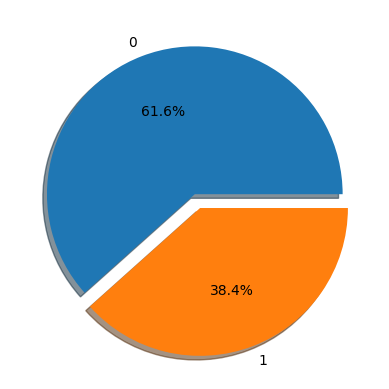

In [20]:
df_train["Survived"].value_counts().plot.pie(explode=[0,0.1], autopct='%1.1f%%', shadow=True)
plt.show()

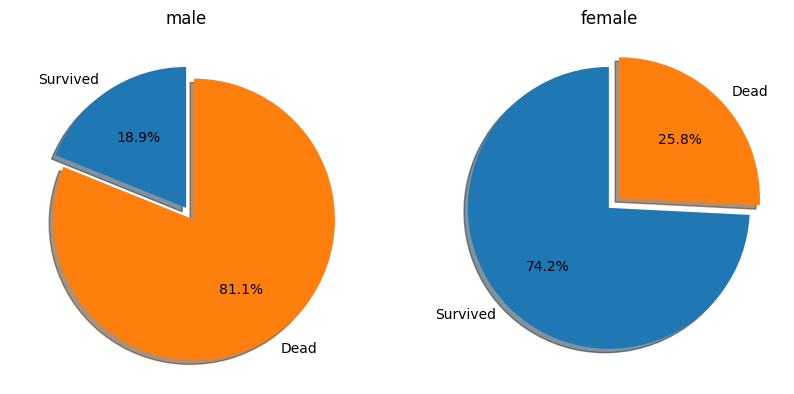

In [21]:
labels = 'Survived', 'Dead'
sizes_m = [len(df_train.loc[ (df_train["Sex"]=='male') & (df_train["Survived"]==1)]), \
         len(df_train.loc[ (df_train["Sex"]=='male')& (df_train["Survived"]==0)]) ]

sizes_f = [len(df_train.loc[ (df_train["Sex"]=='female') & (df_train["Survived"]==1)]), \
         len(df_train.loc[ (df_train["Sex"]=='female')& (df_train["Survived"]==0)]) ]

explode = (0, 0.1)  #굳이 안 해도 됨.

fig = plt.figure()
fig.set_size_inches(10,5)
ax1 = fig.add_subplot(1,2,1) #가로배치니 1열 2행구조
ax2 = fig.add_subplot(1,2,2)

ax1.pie(sizes_m, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.set_title('male')  

ax2.pie(sizes_f, explode=explode, labels=labels, autopct='%1.1f%%',shadow=True, startangle=90)
ax2.set_title('female')  

plt.show()

In [23]:
total_set["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [28]:
total_set["Sex"] = total_set["Sex"].replace({"male":0, "female":1})
# total_set["Sex"] = toal_set["Sex"].apply(lambda s : 0 if s == 'femaile' else 1)

In [29]:
total_set.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


In [30]:
pd.crosstab(train_data.Pclass,train_data.Survived,margins=True).style.background_gradient(cmap='summer_r') 
# margins=True는 합계를 나타낸다. -> ALl

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


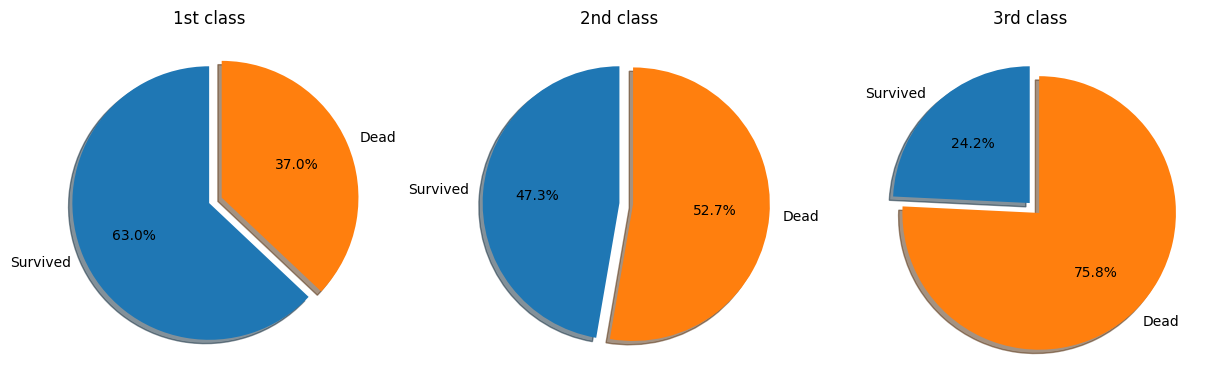

In [31]:
labels = 'Survived', 'Dead'
sizes_1 = [len(train_data.loc[ (train_data["Pclass"]==1) & (train_data["Survived"]==1)]), 
         len(train_data.loc[ (train_data["Pclass"]==1)& (train_data["Survived"]==0)]) ]

sizes_2 = [len(train_data.loc[ (train_data["Pclass"]==2) & (train_data["Survived"]==1)]), 
         len(train_data.loc[ (train_data["Pclass"]==2)& (train_data["Survived"]==0)]) ]

sizes_3 = [len(train_data.loc[ (train_data["Pclass"]==3) & (train_data["Survived"]==1)]), 
         len(train_data.loc[ (train_data["Pclass"]==3)& (train_data["Survived"]==0)]) ]

explode = (0, 0.1)  
fig = plt.figure()
fig.set_size_inches(15,5)
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

ax1.pie(sizes_1, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.set_title('1st class')  

ax2.pie(sizes_2, explode=explode, labels=labels, autopct='%1.1f%%',shadow=True, startangle=90)
ax2.set_title('2nd class')  

ax3.pie(sizes_3, explode=explode, labels=labels, autopct='%1.1f%%',shadow=True, startangle=90)
ax3.set_title('3rd class') 

plt.show()

In [33]:
pd.crosstab([train_data.Pclass,train_data.Sex],train_data.Survived,margins=True).style.background_gradient(cmap='summer_r')

#### AGE

In [34]:
total_set["Age"].isnull().sum()

np.int64(263)

In [35]:
total_set["Age"].describe()

count    1046.000000
mean       29.881138
std        14.413493
min         0.170000
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: Age, dtype: float64

In [36]:
total_set.groupby(["Pclass","Sex"])["Age"].mean()

Pclass  Sex
1       0      41.029272
        1      37.037594
2       0      30.815380
        1      27.499223
3       0      25.962264
        1      22.185329
Name: Age, dtype: float64

In [38]:
total_set

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,108.9000,C
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,8.0500,S


In [40]:
total_set["Age"] = total_set["Age"].fillna(total_set.groupby(["Pclass", "Sex"])["Age"].transform("mean"), inplace=True)

In [41]:
total_set

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",0,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000000,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",1,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000000,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",0,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,25.962264,0,0,A.5. 3236,8.0500,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.000000,0,0,PC 17758,108.9000,C
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,"Ware, Mr. Frederick",0,25.962264,0,0,359309,8.0500,S


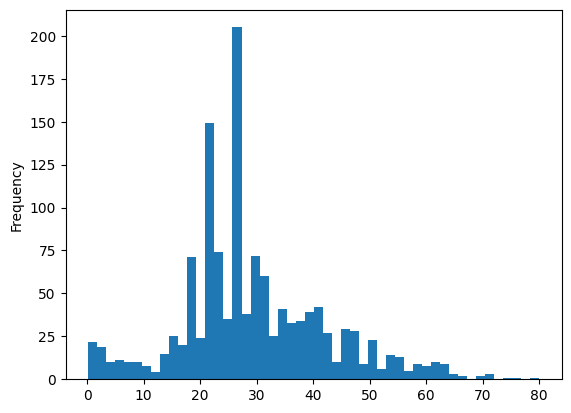

In [42]:
total_set["Age"].plot.hist(bins=50)
plt.show()

In [43]:
total_set["SibSp"].value_counts()

SibSp
0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64

In [44]:
train_data.groupby(["SibSp", "Survived"])["Survived"].count()

SibSp  Survived
0      0           398
       1           210
1      0            97
       1           112
2      0            15
       1            13
3      0            12
       1             4
4      0            15
       1             3
5      0             5
8      0             7
Name: Survived, dtype: int64

In [46]:
total_set['Fare'].describe()

count    1308.000000
mean       33.295479
std        51.758668
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: Fare, dtype: float64

In [49]:
total_set.loc[total_set['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
152,1044,3,"Storey, Mr. Thomas",0,60.5,0,0,3701,NaN,S


In [50]:
total_set['Fare'] = total_set["Fare"].fillna(total_set['Fare'].mean())

In [53]:
total_set.loc[total_set['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


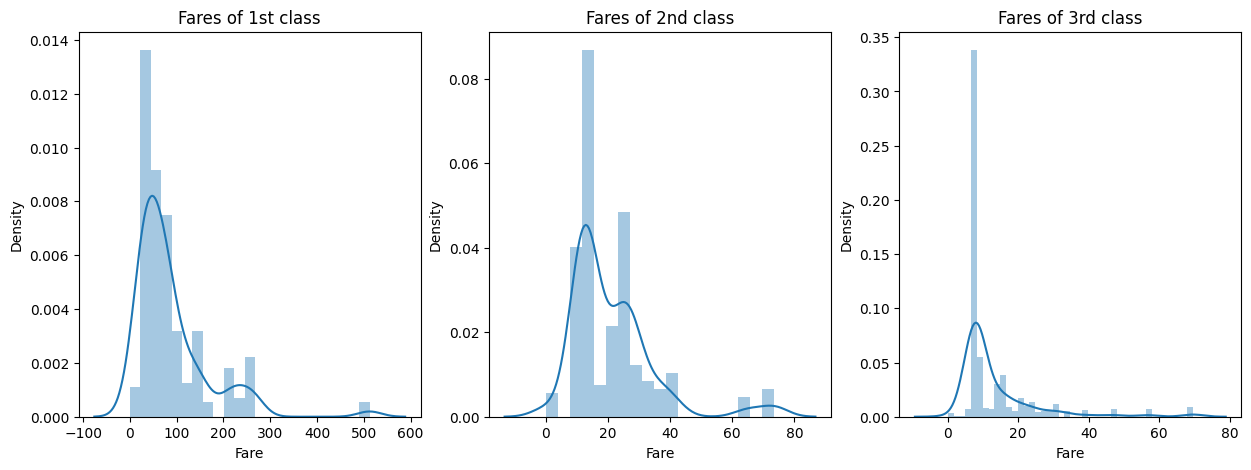

In [54]:
f, ax = plt.subplots(1,3,figsize=(15,5))

sns.distplot( total_set[total_set['Pclass']==1]['Fare'] , ax=ax[0])
ax[0].set_title('Fares of 1st class')
sns.distplot(total_set[total_set['Pclass']==2]['Fare'] , ax=ax[1])
ax[1].set_title('Fares of 2nd class')
sns.distplot(total_set[total_set['Pclass']==3]['Fare'] , ax=ax[2])
ax[2].set_title('Fares of 3rd class')

plt.show()

In [55]:
total_set['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [58]:
total_set['Embarked'].value_counts()

Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [59]:
total_set.loc[total_set['Embarked'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,"Icard, Miss. Amelie",1,38.0,0,0,113572,80.0,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",1,62.0,0,0,113572,80.0,NaN


In [60]:
total_set['Embarked'] = total_set['Embarked'].fillna('S')

In [61]:
total_set.loc[total_set['Embarked'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
